# Anomaly Detection — Category Recap

> **Goal:** flag points that do not belong, given a corpus of (mostly) normal data.

Popular algorithms:

- Isolation Forest
- One-Class SVM (Support Vector Machine)
- LOF (Local Outlier Factor)

## Cheat-sheet — anomaly detection landscape

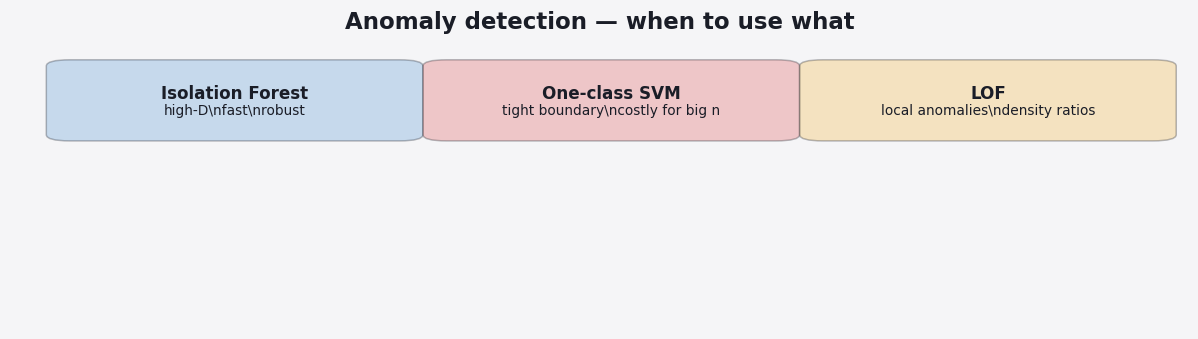

In [17]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
fig, ax = plt.subplots(figsize=(11, 3.2)); ax.axis('off')
ax.text(0.5, 0.96, 'Anomaly detection — when to use what', ha='center', fontsize=15, weight='bold')
items = [('Isolation Forest', 'high-D\\nfast\\nrobust'), ('One-class SVM', 'tight boundary\\ncostly for big n'), ('LOF', 'local anomalies\\ndensity ratios')]
for k, (name, blurb) in enumerate(items):
    r, c = divmod(k, 3)
    x = 0.05 + c*0.32; y = 0.82 - r*0.30
    ax.add_patch(FancyBboxPatch((x, y-0.20), 0.28, 0.22, boxstyle='round,pad=0.02',
                                facecolor=P[k % len(P)], alpha=0.30, edgecolor='#1a1d27'))
    ax.text(x+0.14, y-0.04, name, ha='center', va='top', fontsize=11, weight='bold')
    ax.text(x+0.14, y-0.10, blurb, ha='center', va='top', fontsize=9, wrap=True)
ax.set_xlim(0,1); ax.set_ylim(0,1); plt.tight_layout(); plt.show()


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']


---
## Comparison

| Property | Isolation Forest | One-Class SVM | LOF |
|---|---|---|---|
| Notion | global | global, smooth | **local** |
| Variable-density data | ❌ | ❌ | ✅ |
| High-D (High-Dimensional) | ✅ | ❌ kernel struggles | partial |
| Scale-invariant features | ✅ | ❌ | ❌ |
| Big data ($n > 10^5$) | ✅ | partial | ❌ $O(n^2)$ |
| Online / streaming | partial | partial | ❌ |
| Has `decision_function` | ✅ | ✅ | ✅ |

---
## Decision rule

> **HDBSCAN** = Hierarchical Density-Based Spatial Clustering of Applications with Noise

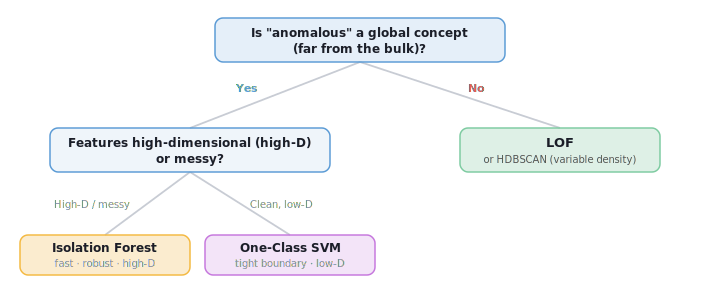

In [19]:
from IPython.display import SVG, display

_svg = """\
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 295" width="720" height="295"
     style="font-family:'DejaVu Sans',sans-serif;background:#f5f5f7;border-radius:8px;">

  <line x1="360" y1="62" x2="190" y2="128" stroke="#c8ccd4" stroke-width="1.8"/>
  <line x1="360" y1="62" x2="560" y2="128" stroke="#c8ccd4" stroke-width="1.8"/>
  <line x1="190" y1="172" x2="105" y2="235" stroke="#c8ccd4" stroke-width="1.8"/>
  <line x1="190" y1="172" x2="290" y2="235" stroke="#c8ccd4" stroke-width="1.8"/>

  <text x="258" y="92"  font-size="11" fill="#5b9bd5" font-weight="bold" text-anchor="end">Yes</text>
  <text x="468" y="92"  font-size="11" fill="#e05c5c" font-weight="bold" text-anchor="start">No</text>
  <text x="130" y="208" font-size="10" fill="#888fa5" text-anchor="end">High-D / messy</text>
  <text x="250" y="208" font-size="10" fill="#888fa5" text-anchor="start">Clean, low-D</text>

  <rect x="215" y="18"  width="290" height="44" rx="8" fill="#5b9bd5" fill-opacity="0.15" stroke="#5b9bd5" stroke-width="1.5"/>
  <text x="360" y="37" text-anchor="middle" font-size="12" font-weight="bold" fill="#1a1d27">Is "anomalous" a global concept</text>
  <text x="360" y="53" text-anchor="middle" font-size="12" font-weight="bold" fill="#1a1d27">(far from the bulk)?</text>

  <rect x="50"  y="128" width="280" height="44" rx="8" fill="#5b9bd5" fill-opacity="0.10" stroke="#5b9bd5" stroke-width="1.5"/>
  <text x="190" y="147" text-anchor="middle" font-size="12" font-weight="bold" fill="#1a1d27">Features high-dimensional (high-D)</text>
  <text x="190" y="163" text-anchor="middle" font-size="12" font-weight="bold" fill="#1a1d27">or messy?</text>

  <rect x="460" y="128" width="200" height="44" rx="8" fill="#7ecba1" fill-opacity="0.25" stroke="#7ecba1" stroke-width="1.5"/>
  <text x="560" y="147" text-anchor="middle" font-size="13" font-weight="bold" fill="#1a1d27">LOF</text>
  <text x="560" y="163" text-anchor="middle" font-size="10" fill="#555555">or HDBSCAN (variable density)</text>

  <rect x="20"  y="235" width="170" height="40" rx="8" fill="#f4b942" fill-opacity="0.25" stroke="#f4b942" stroke-width="1.5"/>
  <text x="105" y="252" text-anchor="middle" font-size="12" font-weight="bold" fill="#1a1d27">Isolation Forest</text>
  <text x="105" y="267" text-anchor="middle" font-size="10" fill="#888fa5">fast · robust · high-D</text>

  <rect x="205" y="235" width="170" height="40" rx="8" fill="#c678dd" fill-opacity="0.20" stroke="#c678dd" stroke-width="1.5"/>
  <text x="290" y="252" text-anchor="middle" font-size="12" font-weight="bold" fill="#1a1d27">One-Class SVM</text>
  <text x="290" y="267" text-anchor="middle" font-size="10" fill="#888fa5">tight boundary · low-D</text>

</svg>"""

display(SVG(_svg))

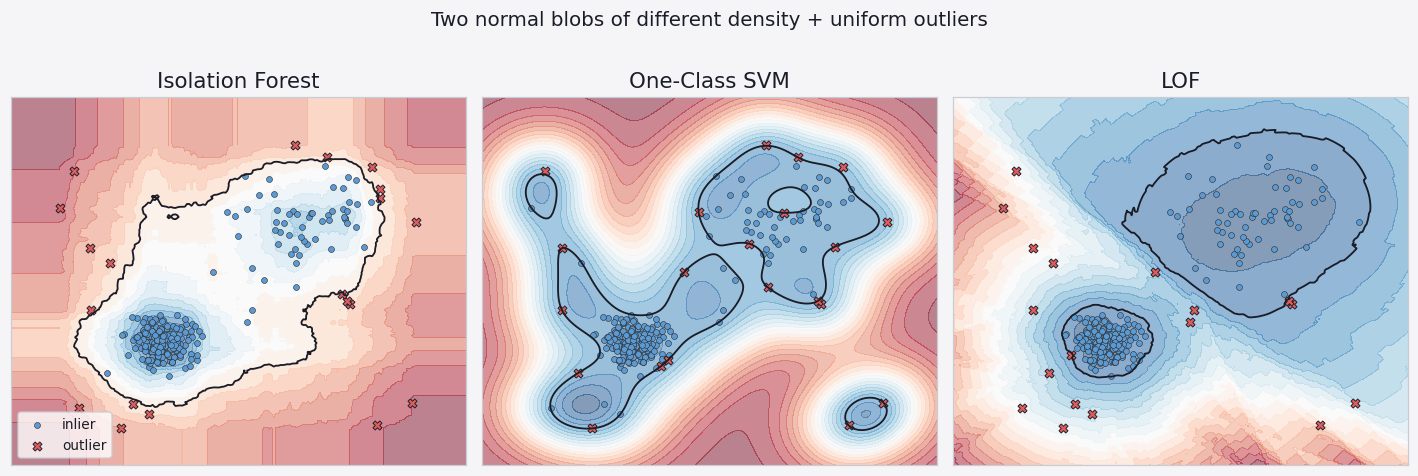

In [20]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

rng = np.random.RandomState(0)
# normal class: two blobs of different density + a sparse arc
n_dense  = 200
n_sparse = 60
X_dense  = rng.normal(loc=[-2, -2], scale=0.4, size=(n_dense, 2))
X_sparse = rng.normal(loc=[ 2,  2], scale=1.0, size=(n_sparse, 2))
X_normal = np.vstack([X_dense, X_sparse])
X_outliers = rng.uniform(low=-5, high=5, size=(20, 2))
X = np.vstack([X_normal, X_outliers])

models = {
    'Isolation Forest': IsolationForest(contamination=0.07, random_state=0).fit(X),
    'One-Class SVM'  : OneClassSVM(gamma='auto', nu=0.07).fit(X),
    'LOF'            : LocalOutlierFactor(n_neighbors=20, contamination=0.07, novelty=True).fit(X),
}

xx, yy = np.meshgrid(np.linspace(-6, 6, 200), np.linspace(-6, 6, 200))
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharex=True, sharey=True)
for ax, (name, m) in zip(axes, models.items()):
    Z = m.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.5)
    ax.contour(xx, yy, Z, levels=[0], colors='#1a1d27', linewidths=1.2)
    pred = m.predict(X)
    ax.scatter(X[pred==1,0],  X[pred==1,1],  s=15, color=PALETTE[0], edgecolors='#333', lw=0.4, label='inlier')
    ax.scatter(X[pred==-1,0], X[pred==-1,1], s=35, color=PALETTE[1], edgecolors='#1a1d27', lw=0.6, marker='X', label='outlier')
    ax.set_title(name)
    ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(loc='lower left', fontsize=9)
fig.suptitle('Two normal blobs of different density + uniform outliers', y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


---
## Reading the panels

- **Isolation Forest** flags points based on global "easy to isolate" — it correctly catches the outliers but also over-flags the sparse blob.
- **One-Class SVM** with default RBF (Radial Basis Function) wraps a smooth boundary around the bulk; its single bandwidth can't represent two densities at once.
- **LOF** is the only method that **respects local density** — points in the sparse blob are *not* outliers because their neighbours are equally sparse.

> Lesson: pick the detector whose **notion of anomaly** matches your domain.